# Stage Z image-metric hill climbing

Optimize HAADF contrast or edge sharpness by moving only `stage.z`. The search uses every measured point to fit a local quadratic response and leaves the stage at the best measured Z position.

Stage Z is an absolute position in meters. Start with a conservative step size and travel limit. If the run errors or is interrupted, the starting Z position is restored.

In [6]:
%matplotlib widget

import json
import os

import matplotlib.pyplot as plt
import numpy as np
import tango
from IPython.display import clear_output, display
from tiled.client import from_uri

TANGO_DATABASE_HOST = "10.46.217.241"
TANGO_DATABASE_PORT = 9094
os.environ["TANGO_HOST"] = f"{TANGO_DATABASE_HOST}:{TANGO_DATABASE_PORT}"

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
stage = tango.DeviceProxy("asyncroscopy/stage/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in (scan, microscope, stage, data):
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

tiled_config = json.loads(data.get_config())
client = from_uri(tiled_config["uri"])
print("Tiled:", tiled_config["uri"])
print(f"Current stage.z: {float(stage.z) * 1e6:+.6f} µm")

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/stage/default ON
asyncroscopy/data/default ON
Tiled: http://10.46.217.241:9091
Current stage.z: +2.699265 µm


## Acquisition and optimizer helpers

Contrast and edge sharpness are calculated for every image. Select which metric drives the optimizer below; larger values are better.

In [7]:
# Options: "contrast", "edge_sharpness"
OPTIMIZATION_METRIC = "contrast"
METRIC_NAMES = ("contrast", "edge_sharpness")

scan.imsize = 512
scan.dwell_time = 2e-6
scan.scan_region = [0, 0, 1, 1]

def read_haadf(key):
    node = client[key]
    if "image" in node:
        node = node["image"]
    if "HAADF" in node:
        node = node["HAADF"]
    return np.asarray(node.read(), dtype=np.float64)

def contrast(image):
    image = np.asarray(image, dtype=np.float64)
    low, high = np.percentile(image, [1, 99])
    clipped = np.clip(image, low, high)
    return float(np.std(clipped) / (abs(np.mean(clipped)) + 1e-12))

def edge_sharpness(image):
    image = np.asarray(image, dtype=np.float64)
    low, high = np.percentile(image, [1, 99])
    clipped = np.clip(image, low, high)
    normalized = clipped / (abs(np.mean(clipped)) + 1e-12)
    gradient_y, gradient_x = np.gradient(normalized)
    return float(np.sqrt(np.mean(gradient_x * gradient_x + gradient_y * gradient_y)))

def acquire_and_measure():
    key = microscope.acquire_scanned_image(["HAADF"])
    image = read_haadf(key)
    metrics = {"contrast": contrast(image), "edge_sharpness": edge_sharpness(image)}
    return metrics, key, image

def optimization_score(metrics):
    if OPTIMIZATION_METRIC not in METRIC_NAMES:
        raise ValueError(f"OPTIMIZATION_METRIC must be one of {METRIC_NAMES}")
    return metrics[OPTIMIZATION_METRIC]

def fit_response(history):
    z_m = np.asarray([item["stage_z_m"] for item in history])
    scores = np.asarray([item[OPTIMIZATION_METRIC] for item in history])
    center = z_m.mean()
    scale = max(z_m.std(), 1e-12)
    x = (z_m - center) / scale
    design = np.column_stack([np.ones(len(x)), x, x * x])
    ridge = 1e-6 * np.eye(design.shape[1])
    coefficients = np.linalg.solve(design.T @ design + ridge, design.T @ scores)

    def predict(candidate_z_m):
        candidate = np.atleast_1d(candidate_z_m)
        x = (candidate - center) / scale
        return np.column_stack([np.ones(len(x)), x, x * x]) @ coefficients

    return predict

def propose_next_z(history, trust_radius_m, starting_z_m, max_offset_m):
    measured_z = np.asarray([item["stage_z_m"] for item in history])
    scores = np.asarray([item[OPTIMIZATION_METRIC] for item in history])
    best_z = measured_z[int(np.argmax(scores))]
    lower = max(best_z - trust_radius_m, starting_z_m - max_offset_m)
    upper = min(best_z + trust_radius_m, starting_z_m + max_offset_m)
    candidates = np.linspace(lower, upper, 401)
    separation = np.min(np.abs(candidates[:, None] - measured_z[None, :]), axis=1)
    candidates = candidates[separation > max(trust_radius_m / 40, 1e-12)]
    if not len(candidates):
        return None
    predict = fit_response(history)
    return float(candidates[int(np.argmax(predict(candidates)))])

def show_progress(history, image, key, starting_z_m, trust_radius_m):
    clear_output(wait=True)
    z_m = np.asarray([item["stage_z_m"] for item in history])
    scores = np.asarray([item[OPTIMIZATION_METRIC] for item in history])
    offsets_nm = (z_m - starting_z_m) * 1e9
    best_index = int(np.argmax(scores))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title(f"{key}\noptimizing {OPTIMIZATION_METRIC.upper()}")
    axes[0].axis("off")

    colors = {"contrast": "tab:orange", "edge_sharpness": "tab:blue"}
    for metric in METRIC_NAMES:
        values = np.asarray([item[metric] for item in history])
        active = metric == OPTIMIZATION_METRIC
        label = f"{metric}{'  ← optimizing' if active else ''}"
        axes[1].plot(values / (values[0] + 1e-12), marker="o", color=colors[metric], linewidth=2.8 if active else 1.2, label=label)
    axes[1].axhline(1, color="0.7", linewidth=0.8)
    axes[1].set(xlabel="acquisition", ylabel="relative to baseline", title="metric history")
    axes[1].legend(frameon=False, fontsize=8)
    axes[1].grid(alpha=0.2)

    margin = max(np.ptp(offsets_nm) * 0.2, trust_radius_m * 1e9, 1.0)
    grid_nm = np.linspace(offsets_nm.min() - margin, offsets_nm.max() + margin, 500)
    if len(history) >= 3:
        predict = fit_response(history)
        axes[2].plot(grid_nm, predict(starting_z_m + grid_nm * 1e-9), color="tab:blue", linewidth=2, label="quadratic fit")
    axes[2].plot(offsets_nm, scores, color="0.7", linewidth=0.8)
    axes[2].scatter(offsets_nm, scores, c=scores, cmap="viridis", edgecolor="white", s=60, zorder=3)
    axes[2].scatter(offsets_nm[best_index], scores[best_index], marker="*", s=190, color="tab:red", label="best")
    axes[2].set(xlabel="stage.z offset from start (nm)", ylabel=OPTIMIZATION_METRIC, title=f"{OPTIMIZATION_METRIC} vs stage.z")
    axes[2].legend(frameon=False)
    axes[2].grid(alpha=0.2)

    best_z_um = z_m[best_index] * 1e6
    fig.suptitle(f"best stage.z = {best_z_um:+.6f} µm  |  offset = {offsets_nm[best_index]:+.2f} nm")
    display(fig)
    plt.close(fig)

def hill_climb_stage_z(step_size_m, max_iterations=8, min_step_size_m=None, max_offset_m=2e-6):
    """One-dimensional quadratic response search using every measured point."""
    step = float(step_size_m)
    min_step = float(min_step_size_m if min_step_size_m is not None else step / 16)
    max_offset = float(max_offset_m)
    starting_z = float(stage.z)
    trust_radius = step
    history = []
    completed = False

    if step <= 0 or max_offset <= 0:
        raise ValueError("Step size and maximum offset must be positive")
    if step > max_offset:
        raise ValueError("Z_STEP_SIZE must not exceed MAX_Z_OFFSET")

    def measure_at(target_z, trial):
        lower = starting_z - max_offset
        upper = starting_z + max_offset
        if not lower <= target_z <= upper:
            raise ValueError("Proposed stage Z exceeds MAX_Z_OFFSET")
        stage.z = float(target_z)
        actual_z = float(stage.z)
        metrics, key, image = acquire_and_measure()
        history.append({**metrics, "key": key, "trial": trial, "stage_z_m": actual_z})
        show_progress(history, image, key, starting_z, trust_radius)
        return metrics

    try:
        measure_at(starting_z, "baseline")
        measure_at(starting_z - step, "initial -")
        measure_at(starting_z + step, "initial +")

        for iteration in range(max_iterations):
            previous_best = max(item[OPTIMIZATION_METRIC] for item in history)
            proposal = propose_next_z(history, trust_radius, starting_z, max_offset)
            if proposal is None:
                break
            metrics = measure_at(proposal, f"model {iteration}")
            if optimization_score(metrics) > previous_best * 1.001:
                trust_radius = min(trust_radius * 1.20, step * 2, max_offset)
            else:
                trust_radius *= 0.65
            if trust_radius < min_step:
                break

        best_index = int(np.argmax([item[OPTIMIZATION_METRIC] for item in history]))
        best = history[best_index]
        stage.z = float(best["stage_z_m"])
        final_z = float(stage.z)
        completed = True
    finally:
        if not completed:
            stage.z = starting_z
            print(f"Run did not complete; restored stage.z to {starting_z * 1e6:+.6f} µm")

    best_image = read_haadf(best["key"])
    show_progress(history, best_image, best["key"], starting_z, trust_radius)
    print(f"Stage Z complete; optimized {OPTIMIZATION_METRIC}: {best[OPTIMIZATION_METRIC]:.6g}")
    print(", ".join(f"{metric}={best[metric]:.6g}" for metric in METRIC_NAMES))
    print(f"start={starting_z * 1e6:+.6f} µm, final={final_z * 1e6:+.6f} µm, offset={(final_z - starting_z) * 1e9:+.3f} nm")
    return {"start_z_m": starting_z, "final_z_m": final_z, "optimized_metric": OPTIMIZATION_METRIC, "metrics": {metric: best[metric] for metric in METRIC_NAMES}, "key": best["key"], "history": history}

## Stage Z hill climb

Adjust the step size and maximum allowed displacement before running this cell.

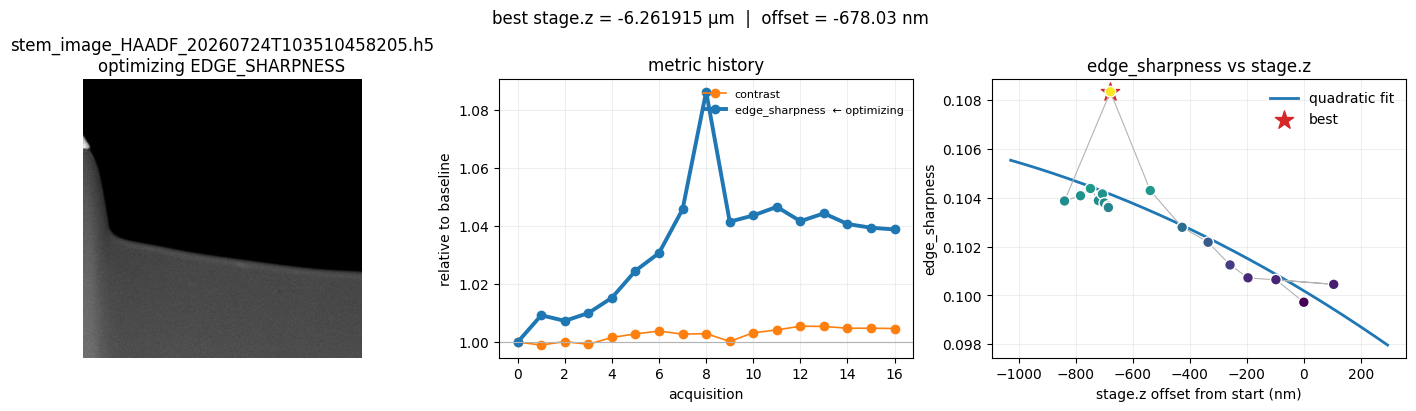

Stage Z complete; optimized edge_sharpness: 0.108328
contrast=1.15485, edge_sharpness=0.108328
start=-5.583885 µm, final=-6.261915 µm, offset=-678.030 nm


In [11]:
Z_STEP_SIZE = 0.1e-6  # meters; adjust this first
Z_MAX_ITERATIONS = 20
MAX_Z_OFFSET = 20e-6  # meters from the starting position; hard safety limit

stage_z_result = hill_climb_stage_z(
    Z_STEP_SIZE,
    max_iterations=Z_MAX_ITERATIONS,
    max_offset_m=MAX_Z_OFFSET,
)

## Optional: restore the starting Z

Run this only if you want to undo the successful optimization.

In [10]:
stage.z = float(stage_z_result["start_z_m"])
print(f"Restored stage.z: {float(stage.z) * 1e6:+.6f} µm")

Restored stage.z: +6.998115 µm
